In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')
import copy

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import SubsetRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.transforms import functional as F
from torch.amp import GradScaler, autocast

# Scikit-learn imports
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Additional utilities
import cv2
from tqdm import tqdm
import gc
from collections import Counter

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    DEVICE = 'cuda'
else:
    print("No GPU available, using CPU")
    DEVICE = 'cpu'

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

No GPU available, using CPU
PyTorch version: 2.4.1+cpu
Device: cpu


In [3]:
class CFG:
    # Data paths
    INPUT_DIR = r'C:\Users\ASUS\Desktop\[ZB]멘토링_프로젝트\Kaggle\Pig_Posture_Recognition\data\pig_posture_recognition'
    OUTPUT_DIR = '/kaggle/working/'
    
    IMAGE_SIZE = 384
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    USE_MIXED_PRECISION = True
    LABEL_SMOOTHING = 0.1
    GRADIENT_ACCUMULATION_STEPS = 1

    N_FOLDS = 5
    SEED = 42
    EARLY_STOPPING_PATIENCE = 10

    NUM_CLASSES = 5
    CLASS_NAMES = ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']

    # 데이터 증강
    AUGMENTATION_PROB = 0.5

    # 디버그 모드
    DEBUG = False

    # TTA configuration
    TTA_COUNT = 10

# 데이터 경로가 존재하는지 확인
if not os.path.exists(CFG.INPUT_DIR):
    print(f'ERROR: 경로가 안 보입니다: {CFG.INPUT_DIR}')
    print("접근 가능한 경로 /kaggle/input/:")
    print(os.listdir('/kaggle/input/'))
else:
    print(f'Input directory 존재: {CFG.INPUT_DIR}')
    print(f'Files available: {os.listdir(CFG.INPUT_DIR)}')

Input directory 존재: C:\Users\ASUS\Desktop\[ZB]멘토링_프로젝트\Kaggle\Pig_Posture_Recognition\data\pig_posture_recognition
Files available: ['pig_posture_classes.txt', 'sample_submission.csv', 'test.csv', 'test_images', 'train.csv', 'train_images']


### 2. 데이터 로드 & EDA

In [4]:
try:
    train_df = pd.read_csv(os.path.join(CFG.INPUT_DIR, 'train.csv'))
    test_df = pd.read_csv(os.path.join(CFG.INPUT_DIR, 'test.csv'))
    print(f"Train data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")

    # 첫 행 확인
    print("\nTrain data sample:")
    print(train_df.head())

except FileNotFoundError as e:
    print(f"ERROR loading data: {e}")
    print(f"Check the correct file names in: {CFG.INPUT_DIR}")
    print(f"Available files: {os.listdir(CFG.INPUT_DIR)}")

Train data shape: (16062, 6)
Test data shape: (6872, 5)

Train data sample:
                row_id      image_id  width  height  \
0  train_00000001_0000  00000001.jpg   1920    1080   
1  train_00000001_0001  00000001.jpg   1920    1080   
2  train_00000001_0002  00000001.jpg   1920    1080   
3  train_00000001_0003  00000001.jpg   1920    1080   
4  train_00000001_0004  00000001.jpg   1920    1080   

                        bbox  class_id  
0  [967.5,331.5,463.0,447.0]         3  
1  [724.5,336.5,324.0,412.0]         3  
2  [430.5,390.5,249.0,457.0]         4  
3   [1199.0,5.5,208.0,282.0]         3  
4    [980.0,5.5,273.0,285.0]         3  


In [5]:
# 기초 데이터 정보
display(f'데이터 컬럼 확인', train_df.columns.tolist())
display(f'Train 데이터 타입:', train_df.dtypes)
display(f'Train 데이터 결측치 확인', train_df.isnull().sum()) # Null 값 확인

display(f'Test 데이터 컬럼 확인', test_df.columns.tolist())
display(f'Test 데이터 결측치 확인', test_df.isnull().sum())

'데이터 컬럼 확인'

['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']

'Train 데이터 타입:'

row_id      object
image_id    object
width        int64
height       int64
bbox        object
class_id     int64
dtype: object

'Train 데이터 결측치 확인'

row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
dtype: int64

'Test 데이터 컬럼 확인'

['row_id', 'image_id', 'width', 'height', 'bbox']

'Test 데이터 결측치 확인'

row_id      0
image_id    0
width       0
height      0
bbox        0
dtype: int64

In [6]:
# 바운딩 박스 데이터 파싱
def parse_box(bbox_str):
    """바운딩 박스 문자열을 float형의 리스트로 파싱"""
    if isinstance(bbox_str, str):
        # [] 제거 후 , 기준으로 나누기
        bbox_str = bbox_str.strip('[]')
        return [float(x.strip()) for x in bbox_str.split(',')]
    return bbox_str

# 바운딩 박스 파싱
train_df['bbox_parsed'] = train_df['bbox'].apply(parse_box)
test_df['bbox_parsed'] = test_df['bbox'].apply(parse_box)

# 각 바운딩 박스 좌표 추출하기
train_df[['xmin', 'ymin', 'width_bbox', 'height_bbox']] = pd.DataFrame(train_df['bbox_parsed'].tolist(), index=train_df.index)
test_df[['xmin', 'ymin', 'width_bbox', 'height_bbox']] = pd.DataFrame(test_df['bbox_parsed'].tolist(), index=test_df.index)

train_df.head()

,row_id,image_id,width,height,bbox,class_id,bbox_parsed,xmin,ymin,width_bbox,height_bbox
0,train_00000001_0000,00000001.jpg,1920,1080,"[967.5,331.5,463.0,447.0]",3,"[967.5, 331.5, 463.0, 447.0]",967.5,331.5,463.0,447.0
1,train_00000001_0001,00000001.jpg,1920,1080,"[724.5,336.5,324.0,412.0]",3,"[724.5, 336.5, 324.0, 412.0]",724.5,336.5,324.0,412.0
2,train_00000001_0002,00000001.jpg,1920,1080,"[430.5,390.5,249.0,457.0]",4,"[430.5, 390.5, 249.0, 457.0]",430.5,390.5,249.0,457.0
3,train_00000001_0003,00000001.jpg,1920,1080,"[1199.0,5.5,208.0,282.0]",3,"[1199.0, 5.5, 208.0, 282.0]",1199.0,5.5,208.0,282.0
4,train_00000001_0004,00000001.jpg,1920,1080,"[980.0,5.5,273.0,285.0]",3,"[980.0, 5.5, 273.0, 285.0]",980.0,5.5,273.0,285.0


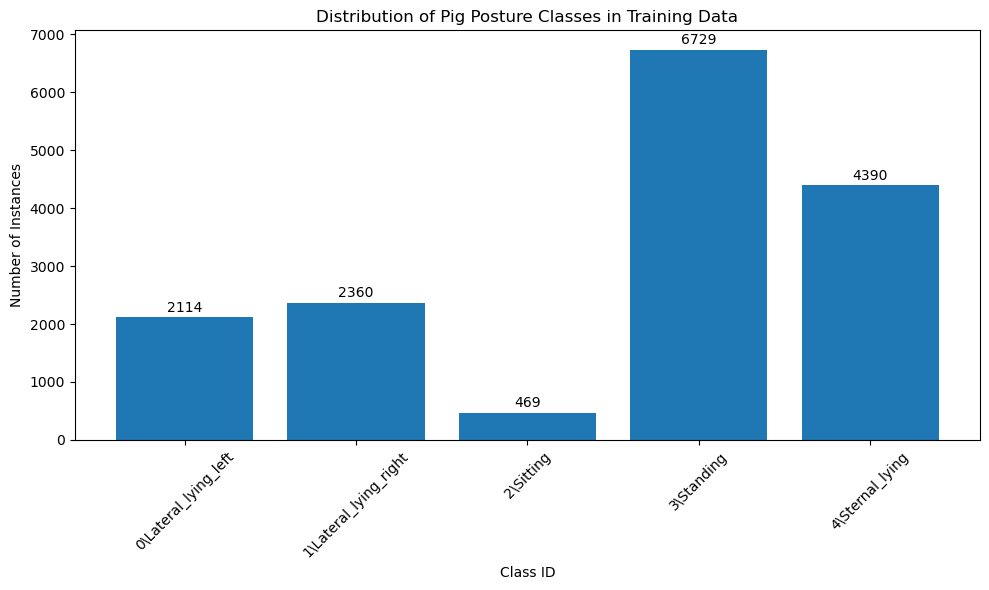


Class Distribution:
Class 0 (Lateral_lying_left): 2114 instances (13.2%)
Class 1 (Lateral_lying_right): 2360 instances (14.7%)
Class 2 (Sitting): 469 instances (2.9%)
Class 3 (Standing): 6729 instances (41.9%)
Class 4 (Sternal_lying): 4390 instances (27.3%)

전체 데이터: 16062
클래스 불균형: 14.35


In [7]:
# Target의 편차 분석
plt.figure(figsize=(10, 6))
class_counts = train_df['class_id'].value_counts().sort_index()
bars = plt.bar(range(len(CFG.CLASS_NAMES)), class_counts.values)
plt.xlabel('Class ID')
plt.ylabel('Number of Instances')
plt.title('Distribution of Pig Posture Classes in Training Data')
plt.xticks(range(len(CFG.CLASS_NAMES)), [f'{i}\{name}' for i, name in enumerate(CFG.CLASS_NAMES)], rotation=45)

# 라벨의 값 더하기

for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
    str(value), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# 편차 통계 출력
print("\nClass Distribution:")
for i, name in enumerate(CFG.CLASS_NAMES):
    count = class_counts[i]
    percentage = (count / class_counts.sum()) * 100
    print(f"Class {i} ({name}): {count} instances ({percentage:.1f}%)")

print(f"\n전체 데이터: {len(train_df)}")
print(f"클래스 불균형: {class_counts.max() / class_counts.min():.2f}")

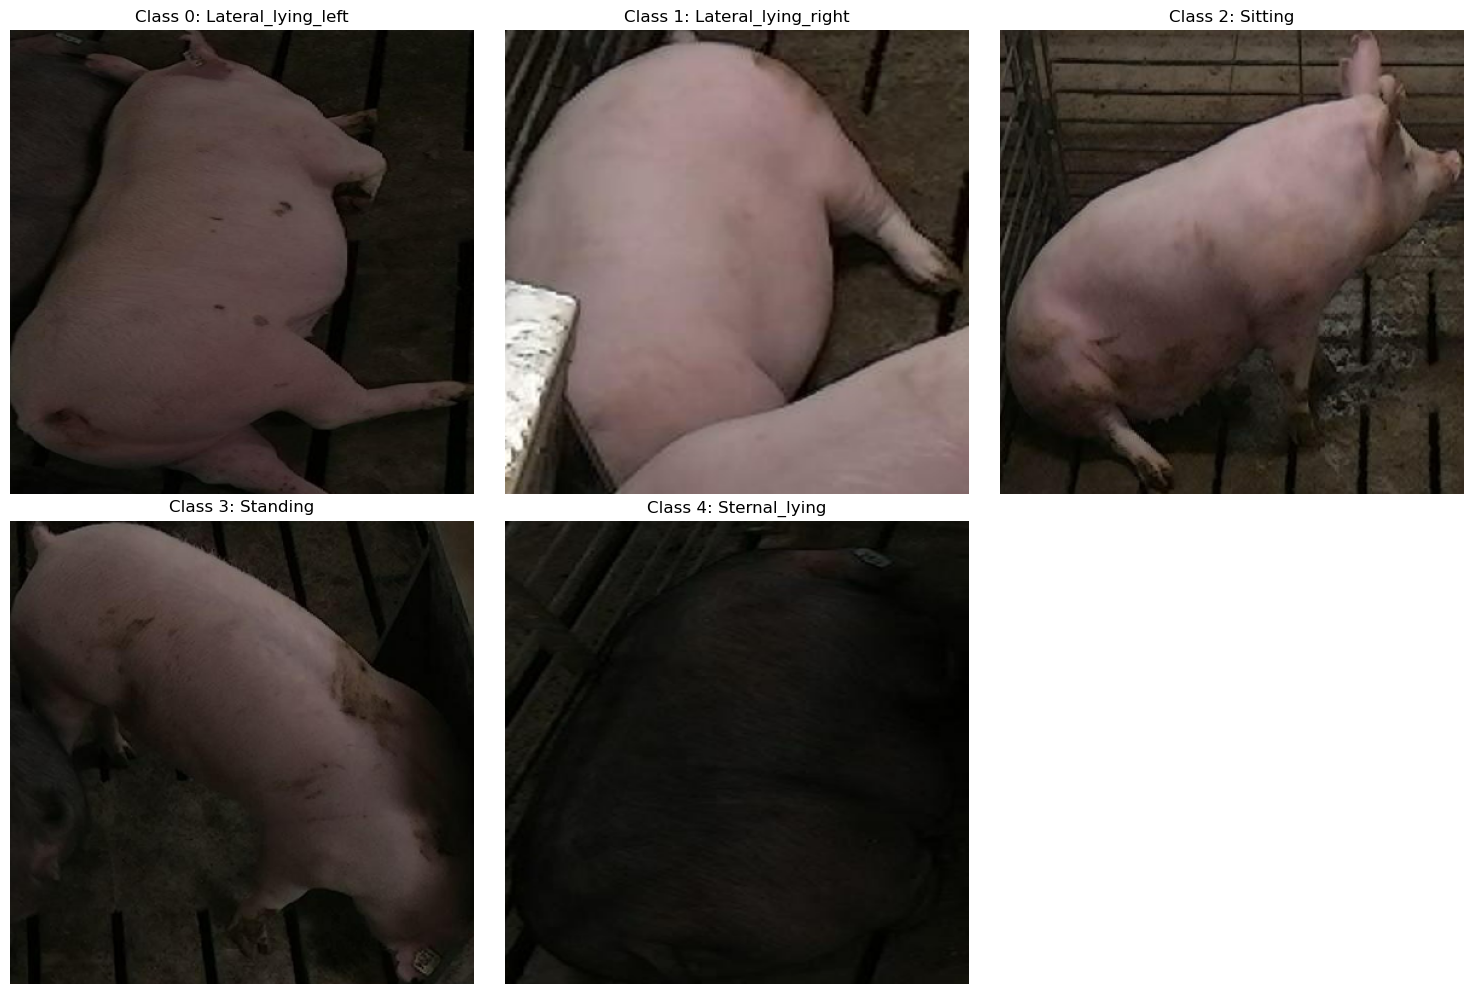

In [8]:
# 이미지 분석 - 각 클래스의 샘플 이미지
def load_and_display_samples():
    """각 클래스의 샘플 이미지 로드 및 시각화"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for class_id in range(CFG.NUM_CLASSES):
        # 샘플 가져오기
        sample = train_df[train_df['class_id'] == class_id].iloc[0] # 첫 번째 사진
        image_path = os.path.join(CFG.INPUT_DIR, 'train_images', sample['image_id'])
        
        try:
            # 이미지 로드
            img = Image.open(image_path).convert("RGB")

            # 바운딩 박스 추출
            xmin, ymin, width_bbox, height_bbox = sample['xmin'], sample['ymin'], sample['width_bbox'], sample['height_bbox']

            # 바운딩박스 영역 자르기
            img_cropped = img.crop((xmin, ymin, xmin + width_bbox, ymin + height_bbox))
            img_cropped = img_cropped.resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))

            # 시각화
            axes[class_id].imshow(img_cropped)
            axes[class_id].set_title(f'Class {class_id}: {CFG.CLASS_NAMES[class_id]}')
            axes[class_id].axis('off')

        except Exception as e:
            print(f'Error loading image {image_path}: {e}')
            axes[class_id].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[class_id].axis('off')

    # 빈 서브플롯은 제거
    if CFG.NUM_CLASSES < len(axes):
        axes[5].remove()
    
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150)
    plt.show()

load_and_display_samples()

### 3. 데이터 전처리 및 증강

In [9]:
# Opencv의 faster loading으로 강화된 데이터셋 클래스
class PigPostureDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, row['image_id'])

        # OpenCV로 로드 (PIL보다 빠름)
        try:
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f'Error loading image {image_path}: {e}')
            image = np.zeros((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE, 3), dtype=np.uint8)

        # 바운딩 박스 파싱
        xmin, ymin, width_bbox, height_bbox = row['xmin'], row['ymin'], row['width_bbox'], row['height_bbox']

        # 안전한 자르기, 만약 돼지 위치가 이미지 범위 벗어나는 것을 방지
        H, W = image.shape[:2]
        xmin = max(0, int(xmin)) # 0보다 작으면 0으로 고정
        ymin = max(0, int(ymin))
        xmax = min(W, int(xmin + width_bbox)) # 이미지를 넘지 않게 제한
        ymax = min(H, int(ymin + height_bbox))

        # 자르고 리사이즈
        image_cropped = image[ymin:ymax, xmin:xmax]
        if image_cropped.size == 0: # 자르기 실패하면 돌아오기
            image_cropped = image

        # Apply transform - 이미지 가공, 변형
        if self.transform:
            image_cropped = self.transform(image=image_cropped)['image']
        else:
            # 잘라낸 사진 384x384 사이즈로 통일 
            image_cropped = cv2.resize(image_cropped, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))
            # 정규화, 텐서 변환 (H, W, C) -> (3, H, W)
            image_cropped = torch.from_numpy(image_cropped).permute(2, 0, 1).float() / 255.0

        if self.is_test:
            return image_cropped, row['row_id']
        else:
            return image_cropped, row['class_id']

print("커스텀 데이터셋 클래스가 성공적으로 정의되었습니다!")

커스텀 데이터셋 클래스가 성공적으로 정의되었습니다!


In [10]:
pip install albumentations


  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] 액세스가 거부되었습니다: 'c:\\Users\\ASUS\\anaconda3\\envs\\ds_study\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [11]:
# 강화된 데이터 증강 변형
import albumentations as A
from albumentations.pytorch import ToTensorV2
# ToTensorV2 - 고성능 데이터 증강 도구와 연동 가능

# 심화 증강법으로 훈련 데이터 변환
train_transforms = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    # 이미지 밀기, 확대, 축소, 45도 미세회전
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    # 밝기, 대비, 채도 
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    # 미세 노이즈 지지직
    A.GaussNoise(p=0.1),
    # 모션 블러
    A.MotionBlur(p=0.1),
    # 이미지 일부를 가림
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 검증/테스트 변환
val_transforms = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("심화된 기법으로 데이터 증강 변환")
print(f"훈련셋: {len(train_transforms)}개 기법")
print(f"검증셋: {len(val_transforms)}개 기법")

심화된 기법으로 데이터 증강 변환
훈련셋: 11개 기법
검증셋: 3개 기법


In [12]:
# 클래스 불균형 해결 위해 클래스 가중치 계산
class_weights = compute_class_weight(
    'balanced', # 데이터가 적을수록 가중치가 높아짐
    classes=np.unique(train_df['class_id']),
    y=train_df['class_id'].values
)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)

print("클래스 가중치: ")
for i, (name, weight) in enumerate(zip(CFG.CLASS_NAMES, class_weights)):
    print(f"클래스 {i} ({name}): {weight:.3f}")

클래스 가중치: 
클래스 0 (Lateral_lying_left): 1.520
클래스 1 (Lateral_lying_right): 1.361
클래스 2 (Sitting): 6.849
클래스 3 (Standing): 0.477
클래스 4 (Sternal_lying): 0.732


### 4. 모델 학습 (3가지 방법)

1. **혼합 정밀도, 라벨 스무딩과 EfficientNetV2-S**
- 혼합 정밀도: 모델 연산시 32비트 소수점 대신 16비트 섞어서 학습속도 증가, 메모리 적게 차지 -> 큰 이미지나 배치 다룰 수 있음
- 라벨 스무딩: 100% 대신 90% 정도만 확신하고 나머지 10% 가능성 열고, 과적합 방지
2. **3-fold 교차 검증과 ResNet-50 앙상블**

3. **추론 시 증강(5 transform)**
- 추론 시 여러가지 변형하며 추론 -> 점수 1~2% 끌어올림

In [13]:
# Method 1
class EfficientNetV2Model(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetV2Model, self).__init__()

        # EfficientNetV2-S (EfficientNet-B3 보다 좋음)
        seights = models.EfficientNet-V2_S_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_v2_s(weights=weights)

        # 향상된 분류기
        in_features = self.backbone.classifier
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNormal1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

print('방법 1: EfficientNetV2-S 모델 정의')

방법 1: EfficientNetV2-S 모델 정의


In [14]:
# 복합 정밀도와 기울기 축적으로 향상된 학습 함수
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, schedulat=None):
    best_val_f1 = 0.0
    best_model_state = None
    patience_ciunter = 0

    # 혼합 정밀도 scaler
    scaler = GradScaler(device='cuda') if CFG.USE_MIXED_PRECISION else None

    train_losses = []
    val_losses = []
    val_f1_scores = []

    for epoch in range(num_epochs):
        # 학습
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} = Training')
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)

            # 혼합 정밀도 훈련
            if CHF.USE_MIXED_PRECISION:
                with autocast(device_map='cuda'): # 16비트로 전환하여 학습
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                # 경사 누적
                loss = loss / CFG.GRADIENT_ACCUMULATION_STEPS
                scaler.scale(loss).backward()

                # 누적 횟수가 꽉 차면 모델 업데이트
                if (batch_idx + 1) % CFG.GRADIENT_ACCUMULATION_STEPS == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            train_loss += loss.item() * CFG.GRADIENT_ACCUMULATION_STEPS
            pbar.set_postfix({'loss': f'{loss.item * CFG.GRADIENT_ACCUMULATION_STEPS:.4f}'})

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 검증
        model.eval()
        val_loss = 0.0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Validation'):
                images, labels = images.to(device), labels.to(device)

                if CFG.USE_MIXED_PRECISION:
                    with autocast(device_mtype='cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)         

                val_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy()) 

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # metrics 계산
        if schedular:
            schedular.step()

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CFG.EARLY_STOPPING_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

    return best_model_state, train_losses, val_losses, val_f1_scores

print("향상된 훈련 함수 정의 밑 혼합 정밀도")

향상된 훈련 함수 정의 밑 혼합 정밀도


In [ ]:
# 방법 1: EfficientNetV2-S 훈련
print('===  METHOD 1: EfficientNetV2-S Training ===')

# 향상된 데이터셋 생성
train_dataset = PigPostureDataset(
    train_df,
    os.path.join(CFG.INPUT_DIR, 'train_images'),
    transform=train_transforms
)

# 검증 데이터 나누기
train_indices, val_indices = train_test_split(
    range(len(train_df)),
    test_size=0.2,
    stratify=train_df['class_id'],
    random_state=CFG.SEED
)

# 아래 코드는 train_dataset을 참조하기 때문에 deepcopy() 해야함.
"""
# 서브 데이터셋 생성
train_subset = torch.utils.data.Subset(train_dataset, train_indices)
val_subset = torch.utils.data.Subset(train_dataset, val_indices)


# # 다른 변형 넣기
# train_subset.dataset.transform = train_transforms
# val_subset.dataset.transform = val_transforms
"""

# 다시 작성
# 서브 데이터셋 생성
train_ds = copy.deepcopy(train_dataset)
val_ds = copy.deepcopy(train_dataset)

train_subset = torch.utils.data.Subset(train_ds, train_indices)
val_subset = torch.utils.data.Subset(val_ds, val_indices)

train_subset.dataset.transform = train_transforms
val_subset.dataset.transform = val_transforms

# 데이터로더 생성
train_loader = DataLoader(
    train_subset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

===  METHOD 1: EfficientNetV2-S Training ===
Training samples: 12849
Validation samples: 3213
Training batches: 402
Validation batches: 101


In [ ]:
# 모델 1 훈련
